# Latent Capacity Sweep

Full sweep across datasets, training-network counts, frames per network, and latent dimensions. The notebook saves model bundles plus summary tables for initial latent-to-p-ratio readout, autoregressive rollouts from 10 to 100 steps, and direct +100 latent jumps.


In [1]:
from __future__ import annotations

import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch_geometric.data import Data
from torch_geometric.utils import to_dense_batch

from graph_utils import calc_p_ratio_rollout_sides, draw_graph, pyg_to_networkx, remove_periodic_edges
from course_project.data import load_dataset, resolve_dataset_splits
from course_project.graph import clone_graph
from course_project.utils import resolve_device

plt.rcParams['figure.dpi'] = 120



/home/alexz/Documents/course_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = random.SystemRandom().randrange(1, 2**31)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
print('run seed:', seed)

# Full paper sweep.
sweep_dataset_names = ['depablo']

dataset_specs = {
    'reid': {
        'label': 'Reid',
        'path': '../data/new_reid_combined.pt',
        'val_count': 30,
    },
    'depablo': {
        'label': 'dePablo OOL',
        'path': '../data/2340_dePablo_networks_OOL_undirected.pt',
        'val_count': 30,
    },
}

latent_dims = [1, 2, 4, 8, 12, 20]
train_counts = [1, 2, 5, 10, 20]
train_frame_counts = [2, 10, 25, 50, 100]
train_frame_counts = [25]
ae_target_modes = ['delta']
sweep_repeats = 3

cfg = {
    'dataset_names': sweep_dataset_names,
    'latent_tokens': 12,
    'hidden_size': 90,
    'edge_feature_dim': 8,
    'pos_dim': 2,
    'batch_graphs': 8,
    'frame_skip': 1,
    'train_frame_start_order': 1,
    'ae_max_epochs': 250,
    'ae_patience': 3,
    'ae_lr': 3e-4,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 250,
    'dyn_patience': 3,
    'dyn_lr': 1e-4,
    'dyn_weight_decay': 1e-5,
    'propagator_loss': 'delta',
    'propagator_model': None,
    'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': list(range(10, 301, 10)),
    'summary_rollout_step': 100,
    'sweep_eval_splits': ['test'],
    'eval_max_sims_per_split': None,
    'keep_trained_models': True,
    'force_training': True,
    'resume_completed_sweep': True,
    'load_cached_sweep_tables': False,
    'node_feature_mode': 'delta',
    'ae_target_modes': ae_target_modes,
    'sweep_repeats': sweep_repeats,
    'show_tables': False,
    'split_seed': seed,
    'shuffle_dataset_within_source': True,
    'min_train_p_ratio': None,
    'device': 'auto',
    'output_root': 'results/latent_space_capacity_sweep/full_sweep',
}


def resolve_existing_path(path_like):
    path = Path(path_like)
    if path.exists():
        return str(path)
    if str(path).startswith('../'):
        repo_relative_path = Path(str(path)[3:])
        if repo_relative_path.exists():
            return str(repo_relative_path)
    return str(path)

for spec in dataset_specs.values():
    spec['path'] = resolve_existing_path(spec['path'])

device = resolve_device(cfg['device'])
run_dir = Path(cfg['output_root'])
run_dir.mkdir(parents=True, exist_ok=True)
print('datasets:', ', '.join(cfg['dataset_names']))
print('device:', device)
print('output:', run_dir)

SHOW_TABLES = bool(cfg.get('show_tables', False))
try:
    _notebook_display = display
except NameError:
    _notebook_display = None

def display(*args, **kwargs):
    if SHOW_TABLES and _notebook_display is not None:
        return _notebook_display(*args, **kwargs)
    return None

if SHOW_TABLES:
    display(pd.DataFrame([cfg]))





run seed: 44458226
datasets: depablo
device: cuda
output: results/latent_space_capacity_sweep/full_sweep


In [3]:
from course_project import latent_simulation as latent_sim_utils

safe_linear_fit_1d = latent_sim_utils.safe_linear_fit_1d
r2_score = latent_sim_utils.r2_score
pearson_r = latent_sim_utils.pearson_r
_shared_latent_pratio_corr_rows = latent_sim_utils.latent_pratio_corr_rows


def filtered_frame_ids(sim, *, include_last=False, max_frames=None, start_frame_order=0):
    return latent_sim_utils.filtered_frame_ids(
        sim,
        frame_skip=cfg.get('frame_skip', 1),
        include_last=include_last,
        max_frames=max_frames,
        start_frame_order=start_frame_order,
    )


def frame_for_filtered_step(sim, filtered_step):
    return latent_sim_utils.frame_for_filtered_step(sim, filtered_step, frame_skip=cfg.get('frame_skip', 1))


def make_frame_index(sims, *, max_frames_per_sim=None, include_last=False, start_frame_order=0):
    return latent_sim_utils.make_frame_index(
        sims,
        frame_skip=cfg.get('frame_skip', 1),
        max_frames_per_sim=max_frames_per_sim,
        include_last=include_last,
        start_frame_order=start_frame_order,
    )


def make_transition_index(sims, *, max_frames_per_sim=None):
    return latent_sim_utils.make_transition_index(
        sims,
        frame_skip=cfg.get('frame_skip', 1),
        max_frames_per_sim=max_frames_per_sim,
    )


def max_filtered_rollout_steps(sims):
    # Common GT horizon for the evaluated split; avoids asking for rollout steps
    # that only some trajectories can support.
    if not sims:
        return 0
    return min(max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0) for sim in sims)


def rollout_steps_for_sims(sims):
    grid = cfg.get('rollout_steps_grid', 'auto')
    max_steps = max_filtered_rollout_steps(sims)
    if max_steps <= 0:
        return []
    if isinstance(grid, str) and grid == 'auto':
        stride = max(1, int(cfg.get('rollout_step_stride', 25)))
        steps = list(range(stride, max_steps + 1, stride))
        if not steps or steps[-1] != max_steps:
            steps.append(max_steps)
        max_eval_steps = cfg.get('rollout_max_eval_steps')
        if max_eval_steps is not None and len(steps) > int(max_eval_steps):
            keep = np.linspace(0, len(steps) - 1, int(max_eval_steps), dtype=int)
            steps = [steps[int(idx)] for idx in keep]
            if steps[-1] != max_steps:
                steps[-1] = max_steps
        return sorted(set(int(step) for step in steps))
    return sorted({min(int(step), max_steps) for step in grid if min(int(step), max_steps) > 0})


def iter_batches(rows, batch_graphs, *, shuffle=True):
    return latent_sim_utils.iter_batches(rows, batch_graphs, shuffle=shuffle)


def edge_features(ref_graph, cur_graph, *, device):
    return latent_sim_utils.edge_features(ref_graph, cur_graph, pos_dim=cfg['pos_dim'], device=device)


def frame_node_feature(sim, t, *, mode, device):
    return latent_sim_utils.frame_node_feature(sim, t, pos_dim=cfg['pos_dim'], mode=mode, device=device)


def batch_delta_graphs(sims, rows, *, device, node_feature_mode='delta'):
    return latent_sim_utils.batch_delta_graphs(
        sims,
        rows,
        pos_dim=cfg['pos_dim'],
        device=device,
        node_feature_mode=node_feature_mode,
    )


def ae_target_tensor(batch_data, target_mode):
    return latent_sim_utils.ae_target_tensor(batch_data, target_mode)


def fit_ae_target_stats(sims, rows, *, device, target_mode):
    return latent_sim_utils.fit_ae_target_stats(
        sims,
        rows,
        pos_dim=cfg['pos_dim'],
        batch_graphs=cfg['batch_graphs'],
        device=device,
        target_mode=target_mode,
    )


def fit_node_feature_stats(sims, rows, *, device, node_feature_mode):
    return latent_sim_utils.fit_node_feature_stats(
        sims,
        rows,
        pos_dim=cfg['pos_dim'],
        batch_graphs=cfg['batch_graphs'],
        device=device,
        node_feature_mode=node_feature_mode,
    )


def fit_edge_stats(sims, rows, *, device):
    return latent_sim_utils.fit_edge_stats(
        sims,
        rows,
        pos_dim=cfg['pos_dim'],
        batch_graphs=cfg['batch_graphs'],
        device=device,
    )


def normalize_ae_target(target):
    return (target - target_mean) / target_std


def unnormalize_ae_target(target_norm):
    return target_norm * target_std + target_mean


def normalize_delta(delta):
    return normalize_ae_target(delta)


def unnormalize_delta(delta_norm):
    return unnormalize_ae_target(delta_norm)


def normalize_node_feature(node_feature):
    return (node_feature - node_feature_mean) / node_feature_std


def normalize_edge_attr(edge_attr):
    return (edge_attr - edge_mean) / edge_std



In [4]:
from course_project.models.latent_space_simulator import (
    LatentDynamicsMLP,
    NodeDeltaAttentionAutoEncoder,
    make_latent_propagator,
)


from course_project import latent_training as latent_train_utils


In [5]:
def encode_frame(model, sim, t, *, device):
    ref_graph = sim[0]
    cur_graph = sim[int(t)]
    ref_pos = ref_graph.x[:, :cfg['pos_dim']].to(device).float()
    node_feature = frame_node_feature(sim, t, mode=node_feature_mode, device=device)
    node_feature_norm = normalize_node_feature(node_feature)
    edge_attr_norm = normalize_edge_attr(edge_features(ref_graph, cur_graph, device=device))
    ref_edge_attr_norm = normalize_edge_attr(edge_features(ref_graph, ref_graph, device=device))
    edge_index = ref_graph.edge_index.to(device).long()
    batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
    z, _ = model.encode(node_feature_norm, ref_pos, edge_attr_norm, ref_edge_attr_norm, edge_index, batch)
    return z.squeeze(0)


def encode_transition_batch(model, sims, rows, *, device):
    z0 = []
    z1 = []
    with torch.no_grad():
        for row in rows:
            if len(row) == 3:
                sim_idx, t0, t1 = row
            else:
                sim_idx, t0 = row
                t1 = int(t0) + 1
            sim = sims[int(sim_idx)]
            z0.append(encode_frame(model, sim, int(t0), device=device))
            z1.append(encode_frame(model, sim, int(t1), device=device))
    return torch.stack(z0, dim=0), torch.stack(z1, dim=0)


def fit_latent_step_stats(model, sims, rows, *, device):
    z_chunks = []
    z_next_chunks = []
    dz_chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        z0, z1 = encode_transition_batch(model, sims, rows_batch, device=device)
        z_chunks.append(z0.detach())
        z_next_chunks.append(z1.detach())
        dz_chunks.append((z1 - z0).detach())
    z_all = torch.cat(z_chunks, dim=0)
    z_next_all = torch.cat(z_next_chunks, dim=0)
    dz_all = torch.cat(dz_chunks, dim=0)
    return {
        'z_mean': z_all.mean(dim=0, keepdim=True),
        'z_std': z_all.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6),
        'dz_mean': dz_all.mean(dim=0, keepdim=True),
        'dz_std': dz_all.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6),
        'z_next_mean': z_next_all.mean(dim=0, keepdim=True),
        'z_next_std': z_next_all.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6),
    }


def normalize_z(z):
    return (z - latent_stats['z_mean']) / latent_stats['z_std']


def normalize_dz(dz):
    return (dz - latent_stats['dz_mean']) / latent_stats['dz_std']


def unnormalize_dz(dz_norm):
    return dz_norm * latent_stats['dz_std'] + latent_stats['dz_mean']


def normalize_z_next(z):
    return (z - latent_stats.get('z_next_mean', latent_stats['z_mean'])) / latent_stats.get('z_next_std', latent_stats['z_std'])


def unnormalize_z_next(z_norm):
    return z_norm * latent_stats.get('z_next_std', latent_stats['z_std']) + latent_stats.get('z_next_mean', latent_stats['z_mean'])


def latent_step(model, z):
    loss_mode = str(globals().get('propagator_loss_mode', cfg.get('propagator_loss', 'delta'))).lower()
    z_norm = normalize_z(z.unsqueeze(0))
    pred = model(z_norm)
    if loss_mode in {'next_z', 'jepa', 'next_embedding'}:
        return unnormalize_z_next(pred).squeeze(0)
    pred_dz_norm = pred - z_norm
    return z + unnormalize_dz(pred_dz_norm).squeeze(0)


def decode_latent_to_graph(ae_model, sim, z, target_index, *, device):
    ref = clone_graph(sim[0]).to(device)
    ref_pos = ref.x[:, :cfg['pos_dim']].float()
    ref_edge_attr_norm = normalize_edge_attr(edge_features(sim[0], sim[0], device=device))
    batch = torch.zeros(ref_pos.size(0), dtype=torch.long, device=device)
    h0 = ae_model.encode_reference_graph(ref_pos, ref_edge_attr_norm, ref.edge_index.to(device).long())
    target_norm = ae_model.decode(z.unsqueeze(0), h0, batch)
    target = unnormalize_ae_target(target_norm)
    pred = clone_graph(sim[target_index]).to(device)
    pred.x = pred.x.clone().float()
    if ae_target_mode in ('position', 'positions'):
        pred.x[:, :cfg['pos_dim']] = target
    else:
        pred.x[:, :cfg['pos_dim']] = ref_pos + target
    return pred.cpu()





In [6]:
def _epoch_ae(model, sims, frame_rows, *, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses = []
    for rows in iter_batches(frame_rows, cfg['batch_graphs'], shuffle=is_train):
        batch_data = batch_delta_graphs(sims, rows, device=device, node_feature_mode=node_feature_mode)
        target_norm = normalize_ae_target(ae_target_tensor(batch_data, ae_target_mode))
        node_feature_norm = normalize_node_feature(batch_data['node_feature'])
        edge_attr_norm = normalize_edge_attr(batch_data['edge_attr'])
        ref_edge_attr_norm = normalize_edge_attr(batch_data['ref_edge_attr'])
        recon_norm, _ = model(node_feature_norm, batch_data['ref_pos'], edge_attr_norm, ref_edge_attr_norm, batch_data['edge_index'], batch_data['batch'])
        loss = F.mse_loss(recon_norm, target_norm)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else float('nan')


def _epoch_dyn(model, ae_model, sims, transition_rows, *, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses = []
    raw_losses = []
    loss_mode = str(globals().get('propagator_loss_mode', cfg.get('propagator_loss', 'delta'))).lower()
    for rows in iter_batches(transition_rows, cfg['batch_graphs'], shuffle=is_train):
        z0, z1 = encode_transition_batch(ae_model, sims, rows, device=device)
        z0_norm = normalize_z(z0)
        pred = model(z0_norm)
        if loss_mode in {'next_z', 'jepa', 'next_embedding'}:
            target_norm = normalize_z_next(z1)
            pred_norm = pred
            pred_raw = unnormalize_z_next(pred_norm)
        else:
            target_norm = normalize_dz(z1 - z0)
            pred_norm = pred - z0_norm
            pred_raw = z0 + unnormalize_dz(pred_norm)
        loss = F.mse_loss(pred_norm, target_norm)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        losses.append(float(loss.item()))
        raw_losses.append(float(F.mse_loss(pred_raw, z1).item()))
    return {
        'loss_norm': float(np.mean(losses)) if losses else float('nan'),
        'loss_raw': float(np.mean(raw_losses)) if raw_losses else float('nan'),
    }


def rollout_position_metrics(df, *, dataset, split_name, rollout_steps):
    if len(df) == 0:
        return {'dataset': dataset, 'split': split_name, 'rollout_steps': rollout_steps, 'used': 0}
    final_pos_mse = float(df['final_pos_mse'].mean())
    initial_to_target_mse = float(df['initial_to_target_mse'].mean())
    movement_fraction_mse = float(final_pos_mse / initial_to_target_mse) if initial_to_target_mse > 0 else float('nan')
    return {
        'dataset': dataset,
        'split': split_name,
        'rollout_steps': int(rollout_steps),
        'used': len(df),
        'p_ratio_r2': r2_score(df['true_p_ratio'], df['pred_p_ratio']),
        'p_ratio_pearson': pearson_r(df['true_p_ratio'], df['pred_p_ratio']),
        'p_ratio_mse': float(np.mean((df['true_p_ratio'] - df['pred_p_ratio']) ** 2)),
        'final_pos_mse': final_pos_mse,
        'initial_to_target_mse': initial_to_target_mse,
        'pred_to_initial_mse': float(df['pred_to_initial_mse'].mean()),
        'movement_fraction_mse': movement_fraction_mse,
        'rollout_position_r2': float(np.clip(1.0 - movement_fraction_mse, 0.0, 1.0)) if np.isfinite(movement_fraction_mse) else float('nan'),
    }


def latent_rollout_eval(ae_model, dyn_model, sims, *, dataset, split_name, rollout_steps):
    rows = []
    ae_model.eval(); dyn_model.eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            filtered_steps = min(int(rollout_steps), max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0))
            target_index = frame_for_filtered_step(sim, filtered_steps)
            if filtered_steps <= 0 or target_index <= 0:
                continue
            z0 = encode_frame(ae_model, sim, 0, device=device)
            z = z0.clone()
            for _ in range(filtered_steps):
                z = latent_step(dyn_model, z)
            pred_graph = decode_latent_to_graph(ae_model, sim, z, target_index, device=device)
            pred_pr = float(calc_p_ratio_rollout_sides([clone_graph(sim[0]).cpu(), pred_graph], -1))
            true_pr = float(calc_p_ratio_rollout_sides(sim, target_index))
            initial_pos = sim[0].x[:, :cfg['pos_dim']].cpu().float()
            target_pos = sim[target_index].x[:, :cfg['pos_dim']].cpu().float()
            pred_pos = pred_graph.x[:, :cfg['pos_dim']].cpu().float()
            initial_to_target_mse = float(F.mse_loss(initial_pos, target_pos).item())
            pred_to_initial_mse = float(F.mse_loss(pred_pos, initial_pos).item())
            final_pos_mse = float(F.mse_loss(pred_pos, target_pos).item())
            movement_fraction_mse = final_pos_mse / initial_to_target_mse if initial_to_target_mse > 0 else float('nan')
            rows.append({
                'dataset': dataset,
                'split': split_name,
                'sim_idx': sim_idx,
                'target_index': target_index,
                'rollout_steps': int(rollout_steps),
                'filtered_steps': int(filtered_steps),
                'pred_p_ratio': pred_pr,
                'true_p_ratio': true_pr,
                'final_pos_mse': final_pos_mse,
                'initial_to_target_mse': initial_to_target_mse,
                'pred_to_initial_mse': pred_to_initial_mse,
                'movement_fraction_mse': movement_fraction_mse,
                'rollout_position_r2': float(np.clip(1.0 - movement_fraction_mse, 0.0, 1.0)) if np.isfinite(movement_fraction_mse) else float('nan'),
            })
    df = pd.DataFrame(rows)
    return df, rollout_position_metrics(df, dataset=dataset, split_name=split_name, rollout_steps=rollout_steps)


def jump_position_pratio_metrics(df, *, dataset, split_name, jump_steps):
    if len(df) == 0:
        return {'dataset': dataset, 'split': split_name, 'jump_steps': int(jump_steps), 'used': 0}
    final_pos_mse = float(df['final_pos_mse'].mean())
    initial_to_target_mse = float(df['initial_to_target_mse'].mean())
    movement_fraction_mse = float(final_pos_mse / initial_to_target_mse) if initial_to_target_mse > 0 else float('nan')
    return {
        'dataset': dataset,
        'split': split_name,
        'jump_steps': int(jump_steps),
        'used': len(df),
        'p_ratio_r2': r2_score(df['true_p_ratio'], df['pred_p_ratio']),
        'p_ratio_pearson': pearson_r(df['true_p_ratio'], df['pred_p_ratio']),
        'p_ratio_mse': float(np.mean((df['true_p_ratio'] - df['pred_p_ratio']) ** 2)),
        'final_pos_mse': final_pos_mse,
        'initial_to_target_mse': initial_to_target_mse,
        'pred_to_initial_mse': float(df['pred_to_initial_mse'].mean()),
        'movement_fraction_mse': movement_fraction_mse,
        'jump_position_r2': float(np.clip(1.0 - movement_fraction_mse, 0.0, 1.0)) if np.isfinite(movement_fraction_mse) else float('nan'),
    }


def make_jump_transition_index(sims, *, jump_steps, max_pairs_per_sim=None):
    rows = []
    for sim_idx, sim in enumerate(sims):
        frame_ids = filtered_frame_ids(sim, include_last=True)
        if len(frame_ids) <= int(jump_steps):
            continue
        starts = list(range(0, len(frame_ids) - int(jump_steps)))
        if max_pairs_per_sim is not None:
            starts = starts[:int(max_pairs_per_sim)]
        for start in starts:
            rows.append((sim_idx, frame_ids[start], frame_ids[start + int(jump_steps)]))
    return rows


def fit_jump_latent_stats(ae_model, sims, rows, *, device):
    z0_chunks = []
    z1_chunks = []
    for rows_batch in iter_batches(rows, cfg['batch_graphs'], shuffle=False):
        z0, z1 = encode_transition_batch(ae_model, sims, rows_batch, device=device)
        z0_chunks.append(z0.detach())
        z1_chunks.append(z1.detach())
    z0_all = torch.cat(z0_chunks, dim=0)
    z1_all = torch.cat(z1_chunks, dim=0)
    return {
        'z0_mean': z0_all.mean(dim=0, keepdim=True),
        'z0_std': z0_all.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6),
        'z1_mean': z1_all.mean(dim=0, keepdim=True),
        'z1_std': z1_all.std(dim=0, keepdim=True, unbiased=False).clamp_min(1e-6),
    }


def _epoch_jump_dyn(model, ae_model, sims, transition_rows, jump_stats, *, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    losses = []
    raw_losses = []
    for rows in iter_batches(transition_rows, cfg['batch_graphs'], shuffle=is_train):
        z0, z1 = encode_transition_batch(ae_model, sims, rows, device=device)
        z0_norm = (z0 - jump_stats['z0_mean']) / jump_stats['z0_std']
        z1_norm = (z1 - jump_stats['z1_mean']) / jump_stats['z1_std']
        pred_z1_norm = model(z0_norm)
        loss = F.mse_loss(pred_z1_norm, z1_norm)
        if is_train:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        pred_z1 = pred_z1_norm * jump_stats['z1_std'] + jump_stats['z1_mean']
        losses.append(float(loss.item()))
        raw_losses.append(float(F.mse_loss(pred_z1, z1).item()))
    return {
        'loss_norm': float(np.mean(losses)) if losses else float('nan'),
        'loss_raw': float(np.mean(raw_losses)) if raw_losses else float('nan'),
    }


def latent_jump_eval(ae_model, jump_model, sims, jump_stats, *, dataset, split_name, jump_steps):
    rows = []
    ae_model.eval(); jump_model.eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            filtered_steps = min(int(jump_steps), max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0))
            target_index = frame_for_filtered_step(sim, filtered_steps)
            if filtered_steps <= 0 or target_index <= 0:
                continue
            z0 = encode_frame(ae_model, sim, 0, device=device)
            z0_norm = (z0.unsqueeze(0) - jump_stats['z0_mean']) / jump_stats['z0_std']
            pred_z_norm = jump_model(z0_norm)
            pred_z = (pred_z_norm * jump_stats['z1_std'] + jump_stats['z1_mean']).squeeze(0)
            pred_graph = decode_latent_to_graph(ae_model, sim, pred_z, target_index, device=device)
            pred_pr = float(calc_p_ratio_rollout_sides([clone_graph(sim[0]).cpu(), pred_graph], -1))
            true_pr = float(calc_p_ratio_rollout_sides(sim, target_index))
            initial_pos = sim[0].x[:, :cfg['pos_dim']].cpu().float()
            target_pos = sim[target_index].x[:, :cfg['pos_dim']].cpu().float()
            pred_pos = pred_graph.x[:, :cfg['pos_dim']].cpu().float()
            initial_to_target_mse = float(F.mse_loss(initial_pos, target_pos).item())
            final_pos_mse = float(F.mse_loss(pred_pos, target_pos).item())
            rows.append({
                'dataset': dataset,
                'split': split_name,
                'sim_idx': sim_idx,
                'target_index': target_index,
                'jump_steps': int(jump_steps),
                'filtered_steps': int(filtered_steps),
                'pred_p_ratio': pred_pr,
                'true_p_ratio': true_pr,
                'final_pos_mse': final_pos_mse,
                'initial_to_target_mse': initial_to_target_mse,
                'pred_to_initial_mse': float(F.mse_loss(pred_pos, initial_pos).item()),
                'movement_fraction_mse': final_pos_mse / initial_to_target_mse if initial_to_target_mse > 0 else float('nan'),
            })
    df = pd.DataFrame(rows)
    return df, jump_position_pratio_metrics(df, dataset=dataset, split_name=split_name, jump_steps=jump_steps)


def latent_rollout_trajectory(ae_model, dyn_model, sim, *, rollout_steps, device):
    ae_model.eval(); dyn_model.eval()
    rows = []
    with torch.no_grad():
        z = encode_frame(ae_model, sim, 0, device=device)
        max_steps = min(int(rollout_steps), max(len(filtered_frame_ids(sim, include_last=True)) - 1, 0))
        for step_idx in range(max_steps + 1):
            target_index = frame_for_filtered_step(sim, step_idx)
            true_pr = float(calc_p_ratio_rollout_sides(sim, target_index))
            row = {
                'step': int(step_idx),
                'frame': int(target_index),
                'true_p_ratio': true_pr,
            }
            z_np = z.detach().cpu().numpy().reshape(-1)
            for dim_idx, value in enumerate(z_np):
                row[f'z{dim_idx}'] = float(value)
            rows.append(row)
            if step_idx < max_steps:
                z = latent_step(dyn_model, z)
    return pd.DataFrame(rows)



In [7]:
def resolve_p_ratio_filtered_train_split(source_spec, p):
    min_train_p_ratio = p.get('min_train_p_ratio')
    if min_train_p_ratio is None:
        return resolve_dataset_splits(
            source_spec['path'],
            train_count=p['train_count'],
            val_count=p['val_count'],
            split_seed=cfg['split_seed'],
            shuffle_within_source=cfg.get('shuffle_dataset_within_source', False),
        )

    sims = load_dataset(source_spec['path'])
    if cfg.get('shuffle_dataset_within_source', False):
        generator = torch.Generator()
        generator.manual_seed(0 if cfg['split_seed'] is None else int(cfg['split_seed']))
        order = torch.randperm(len(sims), generator=generator).tolist()
        sims = [sims[i] for i in order]

    p_ratios = [float(calc_p_ratio_rollout_sides(sim, -1)) for sim in sims]
    train_count = int(p['train_count'])
    val_count = int(p['val_count'])
    eligible_indices = [idx for idx, pr in enumerate(p_ratios) if pr > float(min_train_p_ratio)]
    if len(eligible_indices) < train_count:
        raise ValueError(
            f"Only {len(eligible_indices)} networks have final p-ratio > {min_train_p_ratio}; "
            f"need train_count={train_count}."
        )

    train_indices = set(eligible_indices[:train_count])
    train_data = [sims[idx] for idx in range(len(sims)) if idx in train_indices]
    holdout_data = [sim for idx, sim in enumerate(sims) if idx not in train_indices]
    val_data = holdout_data[:val_count]
    test_data = holdout_data[val_count:]
    train_pr = [p_ratios[idx] for idx in train_indices]
    split_info = [{
        'source': Path(source_spec['path']).stem,
        'path': str(source_spec['path']),
        'total': len(sims),
        'eligible_train': len(eligible_indices),
        'min_train_p_ratio': float(min_train_p_ratio),
        'train': len(train_data),
        'val': len(val_data),
        'test': len(test_data),
        'train_p_ratio_min': float(np.min(train_pr)) if train_pr else float('nan'),
        'train_p_ratio_max': float(np.max(train_pr)) if train_pr else float('nan'),
    }]
    return train_data, val_data, test_data, split_info


def train_one_source(source_spec):
    global target_mean, target_std, delta_mean, delta_std, node_feature_mean, node_feature_std, edge_mean, edge_std, latent_stats, node_feature_mode, ae_target_mode, propagator_loss_mode

    label = source_spec['label']
    p = {**cfg, **source_spec}
    print(f"\n=== {label} ===")
    train_data, val_data, test_data, split_info = resolve_p_ratio_filtered_train_split(source_spec, p)
    print(pd.DataFrame(split_info).to_string(index=False))

    node_feature_mode = p.get('node_feature_mode', 'delta')
    ae_target_mode = p.get('ae_target_mode', 'delta')
    print('node_feature_mode:', node_feature_mode, 'ae_target_mode:', ae_target_mode)
    print('frame_skip:', cfg.get('frame_skip', 1), 'train filtered frames/transitions:', p['max_train_frames_per_sim'])
    train_frames = make_frame_index(train_data, max_frames_per_sim=p['max_train_frames_per_sim'], include_last=True, start_frame_order=p.get('train_frame_start_order', 0))
    val_frames = make_frame_index(val_data, max_frames_per_sim=p['max_train_frames_per_sim'], include_last=True, start_frame_order=p.get('train_frame_start_order', 0))
    target_mean, target_std = fit_ae_target_stats(train_data, train_frames, device=device, target_mode=ae_target_mode)
    delta_mean, delta_std = target_mean, target_std
    node_feature_mean, node_feature_std = fit_node_feature_stats(train_data, train_frames, device=device, node_feature_mode=node_feature_mode)
    edge_mean, edge_std = fit_edge_stats(train_data, train_frames, device=device)
    p['edge_feature_dim'] = int(edge_mean.numel())
    print('edge_feature_dim:', p['edge_feature_dim'])

    ae_model = NodeDeltaAttentionAutoEncoder(
        pos_dim=cfg['pos_dim'], edge_dim=p['edge_feature_dim'], hidden_size=p['hidden_size'],
        latent_dim=p['latent_dim'], latent_tokens=p['latent_tokens'],
    ).to(device)
    ae_opt = torch.optim.AdamW(ae_model.parameters(), lr=p['ae_lr'], weight_decay=p.get('ae_weight_decay', 1e-5))
    best_ae_state = None
    best_val = float('inf')
    stale = 0
    ae_history = []
    print('autoencoder')
    for epoch in range(1, p['ae_max_epochs'] + 1):
        train_loss = _epoch_ae(ae_model, train_data, train_frames, optimizer=ae_opt)
        with torch.no_grad():
            val_loss = _epoch_ae(ae_model, val_data, val_frames, optimizer=None)
        ae_history.append({'dataset': label, 'latent_dim': p['latent_dim'], 'target_mode': ae_target_mode, 'hidden_size': p['hidden_size'], 'epoch': epoch, 'train_mse_norm': train_loss, 'val_mse_norm': val_loss})
        if best_ae_state is None or (np.isfinite(val_loss) and val_loss < best_val - cfg['early_stop_min_delta']):
            best_val = val_loss
            best_ae_state = {k: v.detach().cpu().clone() for k, v in ae_model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if epoch == 1 or epoch % 10 == 0 or stale == 0:
            print(f"ae {epoch:04d} train={train_loss:.6g} val={val_loss:.6g} stale={stale}")
        if stale >= p['ae_patience']:
            break
    if best_ae_state is None:
        best_ae_state = {k: v.detach().cpu().clone() for k, v in ae_model.state_dict().items()}
    ae_model.load_state_dict(best_ae_state)
    ae_model.eval()
    for param in ae_model.parameters():
        param.requires_grad_(False)

    train_steps = make_transition_index(train_data, max_frames_per_sim=p['max_train_frames_per_sim'])
    val_steps = make_transition_index(val_data, max_frames_per_sim=p['max_train_frames_per_sim'])
    latent_stats = fit_latent_step_stats(ae_model, train_data, train_steps, device=device)
    propagator_loss_mode = str(p.get('propagator_loss', cfg.get('propagator_loss', 'delta'))).lower()
    dyn_model = make_latent_propagator(
        p['latent_dim'],
        p['hidden_size'],
        model_type=p.get('propagator_model') or ('direct_mlp' if propagator_loss_mode in {'next_z', 'jepa', 'next_embedding'} else 'residual_mlp'),
    ).to(device)
    dyn_opt = torch.optim.AdamW(dyn_model.parameters(), lr=p['dyn_lr'], weight_decay=p.get('dyn_weight_decay', 1e-5))
    best_dyn_state = None
    best_val = float('inf')
    stale = 0
    dyn_history = []
    print('latent dynamics')
    for epoch in range(1, p['dyn_max_epochs'] + 1):
        train_info = _epoch_dyn(dyn_model, ae_model, train_data, train_steps, optimizer=dyn_opt)
        with torch.no_grad():
            val_info = _epoch_dyn(dyn_model, ae_model, val_data, val_steps, optimizer=None)
        dyn_history.append({'dataset': label, 'latent_dim': p['latent_dim'], 'target_mode': ae_target_mode, 'hidden_size': p['hidden_size'], 'propagator_loss': propagator_loss_mode, 'epoch': epoch, 'train_dz_mse_norm': train_info['loss_norm'], 'val_dz_mse_norm': val_info['loss_norm'], 'val_dz_mse_raw': val_info['loss_raw']})
        if best_dyn_state is None or (np.isfinite(val_info['loss_norm']) and val_info['loss_norm'] < best_val - cfg['early_stop_min_delta']):
            best_val = val_info['loss_norm']
            best_dyn_state = {k: v.detach().cpu().clone() for k, v in dyn_model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if epoch == 1 or epoch % 10 == 0 or stale == 0:
            print(f"dyn {epoch:04d} train={train_info['loss_norm']:.6g} val={val_info['loss_norm']:.6g} stale={stale}")
        if stale >= p['dyn_patience']:
            break
    if best_dyn_state is None:
        best_dyn_state = {k: v.detach().cpu().clone() for k, v in dyn_model.state_dict().items()}
    dyn_model.load_state_dict(best_dyn_state)
    dyn_model.eval()

    rollout_rows = []
    rollout_stats = []
    eval_split_map = {'train': train_data, 'val': val_data, 'test': test_data}
    eval_splits = cfg.get('sweep_eval_splits', ['test'])
    max_eval_sims = cfg.get('eval_max_sims_per_split')
    for split_name in eval_splits:
        sims = eval_split_map[split_name]
        if max_eval_sims is not None:
            sims = sims[:int(max_eval_sims)]
        split_rollout_steps = rollout_steps_for_sims(sims)
        print(f'rollout eval split={split_name}: {max_filtered_rollout_steps(sims)} steps available; evaluating {split_rollout_steps}')
        for steps in split_rollout_steps:
            df, stats = latent_rollout_eval(ae_model, dyn_model, sims, dataset=label, split_name=split_name, rollout_steps=steps)
            rollout_rows.append(df)
            rollout_stats.append(stats)

    rollout_rows_df = pd.concat(rollout_rows, ignore_index=True) if rollout_rows else pd.DataFrame()
    rollout_stats_df = pd.DataFrame(rollout_stats)

    # Jump propagator intentionally disabled: 04b now reports autoregressive rollout only.
    jump_model = None
    jump_latent_stats = {}
    jump_history_df = pd.DataFrame()
    jump_rows_df = pd.DataFrame()
    jump_stats_df = pd.DataFrame()

    return {
        'label': label,
        'params': p,
        'train_data': train_data,
        'val_data': val_data,
        'test_data': test_data,
        'ae': ae_model,
        'dyn': dyn_model,
        'jump': jump_model,
        'stats': {k: v.detach().cpu() if torch.is_tensor(v) else v for k, v in {'target_mean': target_mean, 'target_std': target_std, 'delta_mean': delta_mean, 'delta_std': delta_std, 'node_feature_mean': node_feature_mean, 'node_feature_std': node_feature_std, 'edge_mean': edge_mean, 'edge_std': edge_std, 'ae_target_mode': ae_target_mode, **latent_stats}.items()},
        'jump_latent_stats': {k: v.detach().cpu() if torch.is_tensor(v) else v for k, v in jump_latent_stats.items()},
        'ae_history': pd.DataFrame(ae_history),
        'dyn_history': pd.DataFrame(dyn_history),
        'jump_history': jump_history_df,
        'jump_rows': jump_rows_df,
        'jump_stats': jump_stats_df,
        'rollout_rows': rollout_rows_df,
        'rollout_stats': rollout_stats_df,
    }





## Sweep Setup


In [8]:
def make_sweep_spec(dataset_name, latent_dim, train_count, train_frames, ae_target_mode, repeat_idx):
    dataset_spec = dataset_specs[dataset_name]
    return {
        'label': f'{dataset_spec["label"]} CV{latent_dim} {ae_target_mode} | nets={train_count} | frames={train_frames} | rep={repeat_idx}',
        'target_mode': ae_target_mode,
        'ae_target_mode': ae_target_mode,
        'path': dataset_spec['path'],
        'dataset_name': dataset_name,
        'dataset_label': dataset_spec['label'],
        'train_count': int(train_count),
        'val_count': int(dataset_spec['val_count']),
        'latent_dim': int(latent_dim),
        'latent_tokens': int(cfg['latent_tokens']),
        'hidden_size': int(cfg['hidden_size']),
        'edge_feature_dim': int(cfg['edge_feature_dim']),
        'max_train_frames_per_sim': int(train_frames),
        'node_feature_mode': cfg['node_feature_mode'],
        'propagator_loss': cfg.get('propagator_loss', 'delta'),
        'propagator_model': cfg.get('propagator_model'),
        'sweep_latent_dim': int(latent_dim),
        'sweep_train_count': int(train_count),
        'sweep_train_frames': int(train_frames),
        'sweep_target_mode': ae_target_mode,
        'sweep_repeat': int(repeat_idx),
        'sweep_model_seed': int(seed + 10000019 * (list(cfg['dataset_names']).index(dataset_name) + 1) + 1000003 * int(repeat_idx) + 1009 * int(latent_dim) + 37 * int(train_count) + int(train_frames)),
    }


sweep_specs = [
    make_sweep_spec(dataset_name, latent_dim, train_count, train_frames, ae_target_mode, repeat_idx)
    for dataset_name in cfg['dataset_names']
    for repeat_idx in range(1, int(cfg.get('sweep_repeats', 1)) + 1)
    for ae_target_mode in ae_target_modes
    for latent_dim in latent_dims
    for train_count in train_counts
    for train_frames in train_frame_counts
]
print('planned sweep runs:', len(sweep_specs))
print('datasets:', cfg['dataset_names'])
print('latent dims:', latent_dims)
print('training networks:', train_counts)
print('training frames per network:', train_frame_counts)
print('configured rollout steps before per-split GT cap:', cfg['rollout_steps_grid'])
if SHOW_TABLES:
    display(pd.DataFrame(sweep_specs)[['dataset_name', 'label', 'sweep_target_mode', 'sweep_latent_dim', 'sweep_train_count', 'sweep_train_frames', 'sweep_repeat']].head())





planned sweep runs: 90
datasets: ['depablo']
latent dims: [1, 2, 4, 8, 12, 20]
training networks: [1, 2, 5, 10, 20]
training frames per network: [25]
configured rollout steps before per-split GT cap: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300]


## Run Sweep


In [9]:
sweep_export_dir = run_dir / 'exports'
sweep_export_dir.mkdir(parents=True, exist_ok=True)
sweep_model_dir = run_dir / 'models'
sweep_model_dir.mkdir(parents=True, exist_ok=True)
model_manifest_path = sweep_export_dir / 'sweep_model_manifest.csv'


def sweep_key(spec):
    return (
        str(spec.get('dataset_name', cfg.get('dataset_name', 'unknown'))),
        str(spec['sweep_target_mode']),
        int(spec['sweep_latent_dim']),
        int(spec['sweep_train_count']),
        int(spec['sweep_train_frames']),
        int(spec['sweep_repeat']),
    )


def sweep_model_path(spec):
    dataset_name, target_mode, latent_dim, train_count, train_frames, repeat_idx = sweep_key(spec)
    prop_loss = str(spec.get('propagator_loss', cfg.get('propagator_loss', 'delta'))).lower()
    prop_suffix = '' if prop_loss in {'delta', 'dz', 'residual_delta'} else f'_{prop_loss}'
    name = (
        f'{dataset_name}_{target_mode}_cv{latent_dim:02d}'
        f'_nets{train_count:03d}_frames{train_frames:03d}_rep{repeat_idx:02d}{prop_suffix}.pt'
    )
    return sweep_model_dir / name


def _tensor_to_cpu(value):
    return value.detach().cpu() if torch.is_tensor(value) else value


def _state_dict_to_cpu(model):
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}


def save_sweep_model_bundle(result, spec):
    path = sweep_model_path(spec)
    stats = {key: _tensor_to_cpu(value) for key, value in result['stats'].items()}
    bundle = {
        'spec': dict(spec),
        'params': dict(result['params']),
        'cfg_snapshot': dict(cfg),
        'ae_state_dict': _state_dict_to_cpu(result['ae']),
        'dyn_state_dict': _state_dict_to_cpu(result['dyn']),
        'stats': stats,
        'ae_history': result['ae_history'],
        'dyn_history': result['dyn_history'],
    }
    torch.save(bundle, path)
    return path


def load_sweep_model_bundle(path, *, map_location='cpu'):
    return torch.load(path, map_location=map_location, weights_only=False)


def restore_sweep_model_bundle(bundle, *, device):
    global target_mean, target_std, delta_mean, delta_std, node_feature_mean, node_feature_std, edge_mean, edge_std, latent_stats, node_feature_mode, ae_target_mode, propagator_loss_mode

    p = {**cfg, **bundle['params']}
    stats = bundle['stats']
    node_feature_mode = p.get('node_feature_mode', 'delta')
    ae_target_mode = p.get('ae_target_mode', stats.get('ae_target_mode', 'delta'))

    target_mean = stats['target_mean'].to(device)
    target_std = stats['target_std'].to(device)
    delta_mean = stats.get('delta_mean', target_mean).to(device)
    delta_std = stats.get('delta_std', target_std).to(device)
    node_feature_mean = stats['node_feature_mean'].to(device)
    node_feature_std = stats['node_feature_std'].to(device)
    edge_mean = stats['edge_mean'].to(device)
    edge_std = stats['edge_std'].to(device)
    latent_stats = {
        'z_mean': stats['z_mean'].to(device),
        'z_std': stats['z_std'].to(device),
        'dz_mean': stats['dz_mean'].to(device),
        'dz_std': stats['dz_std'].to(device),
        'z_next_mean': stats.get('z_next_mean', stats['z_mean']).to(device),
        'z_next_std': stats.get('z_next_std', stats['z_std']).to(device),
    }
    propagator_loss_mode = str(p.get('propagator_loss', cfg.get('propagator_loss', 'delta'))).lower()

    ae_model = NodeDeltaAttentionAutoEncoder(
        pos_dim=cfg['pos_dim'],
        edge_dim=int(edge_mean.numel()),
        hidden_size=int(p['hidden_size']),
        latent_dim=int(p['latent_dim']),
        latent_tokens=int(p['latent_tokens']),
    ).to(device)
    ae_model.load_state_dict(bundle['ae_state_dict'])
    ae_model.eval()
    for param in ae_model.parameters():
        param.requires_grad_(False)

    dyn_model = make_latent_propagator(
        int(p['latent_dim']),
        int(p['hidden_size']),
        model_type=p.get('propagator_model') or ('direct_mlp' if propagator_loss_mode in {'next_z', 'jepa', 'next_embedding'} else 'residual_mlp'),
    ).to(device)
    dyn_model.load_state_dict(bundle['dyn_state_dict'])
    dyn_model.eval()
    return ae_model, dyn_model, p



def restore_jump_model_from_bundle(bundle, p, *, device):
    return None, {}

def evaluate_sweep_model_bundle(path, spec=None):
    bundle = load_sweep_model_bundle(path, map_location=device)
    provided_spec = dict(spec or {})
    saved_spec = dict(bundle.get('spec', {}))
    spec = {**provided_spec, **saved_spec}
    spec.setdefault('dataset_name', cfg.get('dataset_name', 'unknown'))
    spec.setdefault('dataset_label', cfg.get('dataset_label', spec.get('dataset_name', 'unknown')))
    ae_model, dyn_model, p = restore_sweep_model_bundle(bundle, device=device)
    _, _, test_data, _ = resolve_p_ratio_filtered_train_split(spec, p)

    rollout_rows = []
    rollout_stats = []
    max_eval_sims = cfg.get('eval_max_sims_per_split')
    eval_sims = test_data[:int(max_eval_sims)] if max_eval_sims is not None else test_data
    eval_rollout_steps = rollout_steps_for_sims(eval_sims)
    for steps in eval_rollout_steps:
        df, stats = latent_rollout_eval(
            ae_model,
            dyn_model,
            eval_sims,
            dataset=spec['label'],
            split_name='test',
            rollout_steps=steps,
        )
        rollout_rows.append(_with_sweep_metadata(df, spec))
        rollout_stats.append(_with_sweep_metadata(pd.DataFrame([stats]), spec))

    rollout_raw = pd.concat(rollout_rows, ignore_index=True) if rollout_rows else pd.DataFrame()
    rollout_stats_df = pd.concat(rollout_stats, ignore_index=True) if rollout_stats else pd.DataFrame()
    jump_stats_df = pd.DataFrame()
    jump_raw = pd.DataFrame()
    jump_history = pd.DataFrame()
    ae_history = _with_sweep_metadata(bundle.get('ae_history', pd.DataFrame()), spec)
    dyn_history = _with_sweep_metadata(bundle.get('dyn_history', pd.DataFrame()), spec)
    summary_row = summarize_sweep_run(spec, rollout_stats_df, ae_history, dyn_history, spec['label'], jump_stats=None)
    summary_row['model_path'] = str(path)

    del ae_model, dyn_model, bundle
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return summary_row, rollout_stats_df, rollout_raw, ae_history, dyn_history, jump_stats_df, jump_raw, jump_history


def _with_sweep_metadata(df, spec):
    df = df.copy()
    df['dataset_name'] = spec.get('dataset_name', cfg.get('dataset_name', 'unknown'))
    df['dataset_label'] = spec.get('dataset_label', cfg.get('dataset_label', 'unknown'))
    df['target_mode'] = spec['sweep_target_mode']
    df['latent_dim'] = spec['sweep_latent_dim']
    df['train_networks'] = spec['sweep_train_count']
    df['train_frames_per_network'] = spec['sweep_train_frames']
    df['repeat_idx'] = spec['sweep_repeat']
    df['model_seed'] = spec['sweep_model_seed']
    return df


def summarize_sweep_run(spec, rollout_stats, ae_hist, dyn_hist, label, jump_stats=None):
    test_rollout = rollout_stats[rollout_stats['split'].eq('test')].copy() if 'split' in rollout_stats.columns else pd.DataFrame()
    if not test_rollout.empty:
        available_steps = sorted(test_rollout['rollout_steps'].dropna().astype(int).unique())
        chosen_step = min(available_steps, key=lambda s: abs(s - int(cfg['summary_rollout_step'])))
        rollout_row = test_rollout[test_rollout['rollout_steps'].eq(chosen_step)].tail(1)
    else:
        chosen_step = int(cfg['summary_rollout_step'])
        rollout_row = pd.DataFrame()

    return {
        'dataset': label,
        'dataset_name': spec.get('dataset_name', cfg.get('dataset_name', 'unknown')),
        'dataset_label': spec.get('dataset_label', cfg.get('dataset_label', 'unknown')),
        'target_mode': spec['sweep_target_mode'],
        'repeat_idx': spec['sweep_repeat'],
        'model_seed': spec['sweep_model_seed'],
        'latent_dim': spec['sweep_latent_dim'],
        'train_networks': spec['sweep_train_count'],
        'train_frames_per_network': spec['sweep_train_frames'],
        'summary_rollout_step': int(chosen_step),
        'frame_skip': int(cfg.get('frame_skip', 1)),
        'test_rollout_final_pos_mse': float(rollout_row['final_pos_mse'].iloc[0]) if not rollout_row.empty and 'final_pos_mse' in rollout_row else float('nan'),
        'test_rollout_initial_to_target_mse': float(rollout_row['initial_to_target_mse'].iloc[0]) if not rollout_row.empty and 'initial_to_target_mse' in rollout_row else float('nan'),
        'test_rollout_pred_to_initial_mse': float(rollout_row['pred_to_initial_mse'].iloc[0]) if not rollout_row.empty and 'pred_to_initial_mse' in rollout_row else float('nan'),
        'test_rollout_movement_fraction_mse': float(rollout_row['movement_fraction_mse'].iloc[0]) if not rollout_row.empty and 'movement_fraction_mse' in rollout_row else float('nan'),
        'test_rollout_position_r2': float(rollout_row['rollout_position_r2'].iloc[0]) if not rollout_row.empty and 'rollout_position_r2' in rollout_row else float('nan'),
        'test_rollout_p_ratio_r2': float(rollout_row['p_ratio_r2'].iloc[0]) if not rollout_row.empty and 'p_ratio_r2' in rollout_row else float('nan'),
        'test_rollout_p_ratio_pearson': float(rollout_row['p_ratio_pearson'].iloc[0]) if not rollout_row.empty and 'p_ratio_pearson' in rollout_row else float('nan'),
        'test_rollout_p_ratio_mse': float(rollout_row['p_ratio_mse'].iloc[0]) if not rollout_row.empty and 'p_ratio_mse' in rollout_row else float('nan'),
        'ae_best_val_mse_norm': float(ae_hist['val_mse_norm'].min()) if 'val_mse_norm' in ae_hist else float('nan'),
        'dyn_best_val_dz_mse_norm': float(dyn_hist['val_dz_mse_norm'].min()) if 'val_dz_mse_norm' in dyn_hist else float('nan'),
        'jump_steps': int(jump_stats['jump_steps'].iloc[0]) if isinstance(jump_stats, pd.DataFrame) and not jump_stats.empty and 'jump_steps' in jump_stats else float('nan'),
        'test_jump_final_pos_mse': float(jump_stats['final_pos_mse'].iloc[0]) if isinstance(jump_stats, pd.DataFrame) and not jump_stats.empty and 'final_pos_mse' in jump_stats else float('nan'),
        'test_jump_movement_fraction_mse': float(jump_stats['movement_fraction_mse'].iloc[0]) if isinstance(jump_stats, pd.DataFrame) and not jump_stats.empty and 'movement_fraction_mse' in jump_stats else float('nan'),
        'test_jump_position_r2': float(jump_stats['jump_position_r2'].iloc[0]) if isinstance(jump_stats, pd.DataFrame) and not jump_stats.empty and 'jump_position_r2' in jump_stats else float('nan'),
        'test_jump_p_ratio_r2': float(jump_stats['p_ratio_r2'].iloc[0]) if isinstance(jump_stats, pd.DataFrame) and not jump_stats.empty and 'p_ratio_r2' in jump_stats else float('nan'),
        'test_jump_p_ratio_pearson': float(jump_stats['p_ratio_pearson'].iloc[0]) if isinstance(jump_stats, pd.DataFrame) and not jump_stats.empty and 'p_ratio_pearson' in jump_stats else float('nan'),
    }


def aggregate_sweep_repeats(summary_df):
    if not isinstance(summary_df, pd.DataFrame) or summary_df.empty:
        return pd.DataFrame()
    df = summary_df.copy()
    if 'repeat_idx' not in df.columns:
        df['repeat_idx'] = 1
    group_cols = ['dataset_name', 'target_mode', 'latent_dim', 'train_networks', 'train_frames_per_network']
    numeric_cols = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col not in ['repeat_idx', 'model_seed'] and col not in group_cols
    ]
    mean_df = df.groupby(group_cols, as_index=False)[numeric_cols].mean()
    repeat_counts = df.groupby(group_cols, as_index=False)['repeat_idx'].nunique().rename(columns={'repeat_idx': 'n_repeats'})
    mean_df = mean_df.merge(repeat_counts, on=group_cols, how='left')
    for metric in ['test_rollout_final_pos_mse', 'test_rollout_movement_fraction_mse', 'test_rollout_position_r2', 'test_rollout_p_ratio_r2', 'test_jump_final_pos_mse', 'test_jump_movement_fraction_mse', 'test_jump_position_r2', 'test_jump_p_ratio_r2', 'ae_best_val_mse_norm', 'dyn_best_val_dz_mse_norm']:
        if metric in df.columns:
            std_df = df.groupby(group_cols, as_index=False)[metric].std().rename(columns={metric: f'{metric}_std'})
            mean_df = mean_df.merge(std_df, on=group_cols, how='left')
    return mean_df


def write_model_manifest():
    rows = []
    for spec in sweep_specs:
        path = sweep_model_path(spec)
        rows.append({
            'dataset_name': spec.get('dataset_name', cfg.get('dataset_name', 'unknown')),
            'dataset_label': spec.get('dataset_label', cfg.get('dataset_label', 'unknown')),
            'target_mode': spec['sweep_target_mode'],
            'latent_dim': spec['sweep_latent_dim'],
            'train_networks': spec['sweep_train_count'],
            'train_frames_per_network': spec['sweep_train_frames'],
            'repeat_idx': spec['sweep_repeat'],
            'model_seed': spec['sweep_model_seed'],
            'model_path': str(path),
            'exists': path.exists(),
        })
    manifest = pd.DataFrame(rows)
    manifest.to_csv(model_manifest_path, index=False)
    return manifest


def _read_csv_if_exists(path):
    path = Path(path)
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def load_cached_sweep_tables():
    paths = {
        'summary': sweep_export_dir / 'sweep_summary.csv',
        'rollout_stats': sweep_export_dir / 'sweep_rollout_stats.csv',
        'rollout_raw': sweep_export_dir / 'sweep_rollout_raw.csv',
        'ae_history': sweep_export_dir / 'sweep_ae_history.csv',
        'dyn_history': sweep_export_dir / 'sweep_dyn_history.csv',
        'jump_stats': sweep_export_dir / 'sweep_jump_stats.csv',
        'jump_raw': sweep_export_dir / 'sweep_jump_raw.csv',
        'jump_history': sweep_export_dir / 'sweep_jump_history.csv',
    }
    required = ['summary', 'rollout_stats']
    if not all(paths[name].exists() for name in required):
        return None
    tables = {name: _read_csv_if_exists(path) for name, path in paths.items()}
    print('loaded cached sweep tables from:', sweep_export_dir)
    for name, table in tables.items():
        if not table.empty:
            print(f'  {name}: {len(table)} rows')
    return tables


def evaluate_saved_sweep_models():
    rows = []
    stats_parts = []
    raw_parts = []
    ae_parts = []
    dyn_parts = []
    jump_stats_parts = []
    jump_raw_parts = []
    jump_history_parts = []
    missing = []
    for spec in sweep_specs:
        path = sweep_model_path(spec)
        if not path.exists():
            missing.append(str(path))
            continue
        print('evaluating saved model:', path.name)
        row, stats, raw, ae_hist, dyn_hist, jump_stats, jump_raw, jump_hist = evaluate_sweep_model_bundle(path, spec)
        rows.append(row)
        stats_parts.append(stats)
        raw_parts.append(raw)
        ae_parts.append(ae_hist)
        dyn_parts.append(dyn_hist)
        jump_stats_parts.append(jump_stats)
        jump_raw_parts.append(jump_raw)
        jump_history_parts.append(jump_hist)
    if missing:
        print(f'{len(missing)} sweep model bundles are missing. Set cfg["force_training"] = True to train them.')
    return (
        pd.DataFrame(rows),
        pd.concat(stats_parts, ignore_index=True) if stats_parts else pd.DataFrame(),
        pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame(),
        pd.concat(ae_parts, ignore_index=True) if ae_parts else pd.DataFrame(),
        pd.concat(dyn_parts, ignore_index=True) if dyn_parts else pd.DataFrame(),
        pd.concat(jump_stats_parts, ignore_index=True) if jump_stats_parts else pd.DataFrame(),
        pd.concat(jump_raw_parts, ignore_index=True) if jump_raw_parts else pd.DataFrame(),
        pd.concat(jump_history_parts, ignore_index=True) if jump_history_parts else pd.DataFrame(),
    )


cached_tables = None
if cfg.get('load_cached_sweep_tables', True) and not cfg.get('force_training', False):
    cached_tables = load_cached_sweep_tables()

if cached_tables is not None:
    sweep_summary_df = cached_tables['summary']
    sweep_rollout_stats_df = cached_tables['rollout_stats']
    sweep_rollout_raw_df = cached_tables['rollout_raw']
    sweep_ae_history_df = cached_tables['ae_history']
    sweep_dyn_history_df = cached_tables['dyn_history']
    sweep_jump_stats_df = cached_tables['jump_stats']
    sweep_jump_raw_df = cached_tables['jump_raw']
    sweep_jump_history_df = cached_tables['jump_history']
elif not cfg.get('force_training', False):
    (
        sweep_summary_df,
        sweep_rollout_stats_df,
        sweep_rollout_raw_df,
        sweep_ae_history_df,
        sweep_dyn_history_df,
        sweep_jump_stats_df,
        sweep_jump_raw_df,
        sweep_jump_history_df,
    ) = evaluate_saved_sweep_models()
else:
    sweep_metric_rows = []
    sweep_rollout_stats_parts = []
    sweep_rollout_raw_parts = []
    sweep_ae_history_parts = []
    sweep_dyn_history_parts = []
    sweep_jump_stats_parts = []
    sweep_jump_raw_parts = []
    sweep_jump_history_parts = []

    completed_keys = set()
    if cfg.get('resume_completed_sweep', False):
        completed_keys = {
            sweep_key(spec)
            for spec in sweep_specs
            if sweep_model_path(spec).exists()
        }
        if completed_keys:
            print(f'Resuming sweep: found {len(completed_keys)} saved model bundles.')

    for run_idx, spec in enumerate(sweep_specs, start=1):
        key = sweep_key(spec)
        if key in completed_keys:
            print(f'evaluate completed {run_idx}/{len(sweep_specs)}: {spec["label"]}')
            row, stats, raw, ae_hist, dyn_hist, jump_stats, jump_raw, jump_hist = evaluate_sweep_model_bundle(sweep_model_path(spec), spec)
            sweep_metric_rows.append(row)
            sweep_rollout_stats_parts.append(stats)
            sweep_rollout_raw_parts.append(raw)
            sweep_ae_history_parts.append(ae_hist)
            sweep_dyn_history_parts.append(dyn_hist)
            sweep_jump_stats_parts.append(jump_stats)
            sweep_jump_raw_parts.append(jump_raw)
            sweep_jump_history_parts.append(jump_hist)
            continue

        run_seed = spec['sweep_model_seed']
        random.seed(run_seed)
        np.random.seed(run_seed % (2**32 - 1))
        torch.manual_seed(run_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(run_seed)

        print(f'### Rollout sweep run {run_idx}/{len(sweep_specs)}: {spec["label"]}')
        result = train_one_source(spec)
        model_path = save_sweep_model_bundle(result, spec)
        print('saved model bundle:', model_path)

        rollout_raw = _with_sweep_metadata(result['rollout_rows'], spec)
        rollout_stats = _with_sweep_metadata(result['rollout_stats'], spec)
        ae_hist = _with_sweep_metadata(result['ae_history'], spec)
        dyn_hist = _with_sweep_metadata(result['dyn_history'], spec)
        jump_stats = _with_sweep_metadata(result.get('jump_stats', pd.DataFrame()), spec)
        jump_raw = _with_sweep_metadata(result.get('jump_rows', pd.DataFrame()), spec)
        jump_hist = _with_sweep_metadata(result.get('jump_history', pd.DataFrame()), spec)
        sweep_rollout_raw_parts.append(rollout_raw)
        sweep_rollout_stats_parts.append(rollout_stats)
        sweep_ae_history_parts.append(ae_hist)
        sweep_dyn_history_parts.append(dyn_hist)
        sweep_jump_stats_parts.append(jump_stats)
        sweep_jump_raw_parts.append(jump_raw)
        sweep_jump_history_parts.append(jump_hist)

        summary_row = summarize_sweep_run(spec, rollout_stats, ae_hist, dyn_hist, result['label'], jump_stats=jump_stats)
        summary_row['model_path'] = str(model_path)
        sweep_metric_rows.append(summary_row)

        completed_keys.add(key)
        write_model_manifest()
        print(f'checkpointed {len(completed_keys)}/{len(sweep_specs)} model bundles')

        if not cfg.get('keep_trained_models', False):
            del result
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    sweep_summary_df = pd.DataFrame(sweep_metric_rows).drop_duplicates(
        subset=['dataset_name', 'target_mode', 'latent_dim', 'train_networks', 'train_frames_per_network', 'repeat_idx'], keep='last'
    )
    sweep_rollout_stats_df = pd.concat(sweep_rollout_stats_parts, ignore_index=True) if sweep_rollout_stats_parts else pd.DataFrame()
    sweep_rollout_raw_df = pd.concat(sweep_rollout_raw_parts, ignore_index=True) if sweep_rollout_raw_parts else pd.DataFrame()
    sweep_ae_history_df = pd.concat(sweep_ae_history_parts, ignore_index=True) if sweep_ae_history_parts else pd.DataFrame()
    sweep_dyn_history_df = pd.concat(sweep_dyn_history_parts, ignore_index=True) if sweep_dyn_history_parts else pd.DataFrame()
    sweep_jump_stats_df = pd.concat(sweep_jump_stats_parts, ignore_index=True) if sweep_jump_stats_parts else pd.DataFrame()
    sweep_jump_raw_df = pd.concat(sweep_jump_raw_parts, ignore_index=True) if sweep_jump_raw_parts else pd.DataFrame()
    sweep_jump_history_df = pd.concat(sweep_jump_history_parts, ignore_index=True) if sweep_jump_history_parts else pd.DataFrame()

# Save the currently loaded/evaluated sweep tables for downstream plotting without rerunning.
sweep_summary_df.to_csv(sweep_export_dir / 'sweep_summary.csv', index=False)
sweep_summary_mean_df = aggregate_sweep_repeats(sweep_summary_df)
sweep_summary_mean_df.to_csv(sweep_export_dir / 'sweep_summary_mean.csv', index=False)
sweep_rollout_stats_df.to_csv(sweep_export_dir / 'sweep_rollout_stats.csv', index=False)
sweep_rollout_raw_df.to_csv(sweep_export_dir / 'sweep_rollout_raw.csv', index=False)
sweep_ae_history_df.to_csv(sweep_export_dir / 'sweep_ae_history.csv', index=False)
sweep_dyn_history_df.to_csv(sweep_export_dir / 'sweep_dyn_history.csv', index=False)
if isinstance(sweep_jump_stats_df, pd.DataFrame) and not sweep_jump_stats_df.empty:
    sweep_jump_stats_df.to_csv(sweep_export_dir / 'sweep_jump_stats.csv', index=False)
if isinstance(sweep_jump_raw_df, pd.DataFrame) and not sweep_jump_raw_df.empty:
    sweep_jump_raw_df.to_csv(sweep_export_dir / 'sweep_jump_raw.csv', index=False)
if isinstance(sweep_jump_history_df, pd.DataFrame) and not sweep_jump_history_df.empty:
    sweep_jump_history_df.to_csv(sweep_export_dir / 'sweep_jump_history.csv', index=False)

sweep_model_manifest_df = write_model_manifest()

if SHOW_TABLES and isinstance(sweep_summary_df, pd.DataFrame) and not sweep_summary_df.empty:
    display(sweep_summary_df.sort_values(['target_mode', 'latent_dim', 'train_networks', 'train_frames_per_network', 'repeat_idx']).round(4))





### Rollout sweep run 1/90: dePablo OOL CV1 delta | nets=1 | frames=25 | rep=1

=== dePablo OOL CV1 delta | nets=1 | frames=25 | rep=1 ===
                              source                                            path  total  train  val  test
2340_dePablo_networks_OOL_undirected ../data/2340_dePablo_networks_OOL_undirected.pt    100      1   30    69
node_feature_mode: delta ae_target_mode: delta
frame_skip: 1 train filtered frames/transitions: 25
edge_feature_dim: 13
autoencoder
ae 0001 train=1.36423 val=0.645376 stale=0
ae 0002 train=1.0837 val=0.621726 stale=0
ae 0003 train=0.72009 val=0.595382 stale=0
ae 0004 train=1.18276 val=0.565286 stale=0
ae 0005 train=0.654388 val=0.52945 stale=0
ae 0006 train=0.747504 val=0.488466 stale=0
ae 0007 train=0.764109 val=0.449412 stale=0
ae 0010 train=0.339604 val=0.752941 stale=3
latent dynamics
dyn 0001 train=0.818583 val=11.598 stale=0
dyn 0004 train=0.777886 val=11.5945 stale=0
rollout eval split=test: 110 steps available; evaluating [10

In [10]:
if isinstance(sweep_summary_mean_df, pd.DataFrame) and not sweep_summary_mean_df.empty:
    cols = [
        'dataset_name', 'target_mode', 'latent_dim', 'train_networks', 'train_frames_per_network', 'n_repeats',
        'test_rollout_final_pos_mse', 'test_rollout_p_ratio_r2',
    ]
    cols = [col for col in cols if col in sweep_summary_mean_df.columns]
    print(sweep_summary_mean_df[cols].sort_values(['dataset_name', 'target_mode', 'train_networks', 'train_frames_per_network', 'latent_dim']).head(80).to_string(index=False))
else:
    print('No sweep summary is loaded yet. Set cfg["force_training"] = True to train model bundles, or run the model-evaluation cell after bundles exist.')




dataset_name target_mode  latent_dim  train_networks  train_frames_per_network  n_repeats  test_rollout_final_pos_mse  test_rollout_p_ratio_r2
     depablo       delta           1               1                        25          3                    0.000434                -0.775760
     depablo       delta           2               1                        25          3                    0.000412                -0.199556
     depablo       delta           4               1                        25          3                    0.000443                -1.636639
     depablo       delta           8               1                        25          3                    0.000411                -0.397615
     depablo       delta          12               1                        25          3                    0.000425                -0.474280
     depablo       delta          20               1                        25          3                    0.000403                -0.510039

## Initial Latent To Final P-ratio Summary


In [11]:
initial_latent_ridge_alpha = 1e-3


def initial_latent_pratio_table(ae_model, sims, *, split_name, spec):
    rows = []
    ae_model.eval()
    with torch.no_grad():
        for sim_idx, sim in enumerate(sims):
            z = encode_frame(ae_model, sim, 0, device=device).detach().cpu().numpy().reshape(-1)
            row = {
                'split': split_name,
                'sim_idx': int(sim_idx),
                'final_p_ratio': float(calc_p_ratio_rollout_sides(sim, -1)),
            }
            for dim_idx, value in enumerate(z):
                row[f'z{dim_idx}'] = float(value)
            rows.append(row)
    return _with_sweep_metadata(pd.DataFrame(rows), spec)


def _finite_xy(X, y):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    return X[mask], y[mask]


def fit_ridge_on_val(X_val, y_val, *, alpha=1e-3):
    X_val, y_val = _finite_xy(X_val, y_val)
    if len(y_val) < 3:
        return None
    x_mean = X_val.mean(axis=0, keepdims=True)
    x_std = X_val.std(axis=0, keepdims=True) + 1e-12
    Xz = (X_val - x_mean) / x_std
    X_aug = np.column_stack([np.ones(len(Xz)), Xz])
    penalty = np.eye(X_aug.shape[1])
    penalty[0, 0] = 0.0
    coef = np.linalg.solve(X_aug.T @ X_aug + float(alpha) * penalty, X_aug.T @ y_val)
    return {'coef': coef, 'x_mean': x_mean, 'x_std': x_std}


def predict_ridge(model, X):
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    Xz = (X - model['x_mean']) / model['x_std']
    X_aug = np.column_stack([np.ones(len(Xz)), Xz])
    return X_aug @ model['coef']


def score_model(model, X, y):
    X, y = _finite_xy(X, y)
    if model is None or len(y) < 3:
        return float('nan'), float('nan')
    pred = predict_ridge(model, X)
    denom = float(np.sum((y - y.mean()) ** 2))
    r2 = float(1.0 - np.sum((y - pred) ** 2) / denom) if denom > 1e-12 else float('nan')
    rmse = float(np.sqrt(np.mean((y - pred) ** 2)))
    return r2, rmse


def evaluate_all_initial_latents():
    raw_parts = []
    for spec in sweep_specs:
        path = sweep_model_path(spec)
        if not path.exists():
            continue
        print('initial latent scan:', path.name)
        bundle = load_sweep_model_bundle(path, map_location=device)
        saved_spec = dict(bundle.get('spec', {}))
        spec = {**spec, **saved_spec}
        spec.setdefault('dataset_name', cfg.get('dataset_name', 'unknown'))
        spec.setdefault('dataset_label', spec.get('dataset_name', 'unknown'))
        ae_model, _, p = restore_sweep_model_bundle(bundle, device=device)
        _, val_data, test_data, _ = resolve_p_ratio_filtered_train_split(spec, p)
        raw_parts.append(initial_latent_pratio_table(ae_model, val_data, split_name='val', spec=spec))
        raw_parts.append(initial_latent_pratio_table(ae_model, test_data, split_name='test', spec=spec))
        del ae_model, bundle
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()


def initial_latent_model_selection(raw_df):
    group_cols = ['dataset_name', 'target_mode', 'latent_dim', 'train_networks', 'train_frames_per_network', 'repeat_idx']
    rows = []
    pred_parts = []
    for key, group in raw_df.groupby(group_cols, sort=False):
        dataset_name, target_mode, latent_dim, train_networks, train_frames, repeat_idx = key
        val = group[group['split'].eq('val')].copy()
        test = group[group['split'].eq('test')].copy()
        z_cols = [f'z{i}' for i in range(int(latent_dim)) if f'z{i}' in group.columns]
        if val.empty or test.empty or not z_cols:
            continue
        coord_rows = []
        for z_col in z_cols:
            model = fit_ridge_on_val(val[[z_col]].to_numpy(float), val['final_p_ratio'].to_numpy(float), alpha=initial_latent_ridge_alpha)
            val_r2, _ = score_model(model, val[[z_col]].to_numpy(float), val['final_p_ratio'].to_numpy(float))
            test_r2, test_rmse = score_model(model, test[[z_col]].to_numpy(float), test['final_p_ratio'].to_numpy(float))
            coord_rows.append({'latent_coordinate': z_col, 'single_model': model, 'val_r2': val_r2, 'single_test_r2': test_r2, 'single_test_rmse': test_rmse})
        coord_df = pd.DataFrame(coord_rows)
        best_coord = coord_df.sort_values(['val_r2', 'single_test_r2'], ascending=[False, False]).iloc[0]
        combo_model = fit_ridge_on_val(val[z_cols].to_numpy(float), val['final_p_ratio'].to_numpy(float), alpha=initial_latent_ridge_alpha)
        combo_test_r2, combo_test_rmse = score_model(combo_model, test[z_cols].to_numpy(float), test['final_p_ratio'].to_numpy(float))
        pred_parts.append(pd.DataFrame({
            'dataset_name': dataset_name,
            'target_mode': target_mode,
            'latent_dim': int(latent_dim),
            'train_networks': int(train_networks),
            'train_frames_per_network': int(train_frames),
            'repeat_idx': int(repeat_idx),
            'split': 'test',
            'sim_idx': test['sim_idx'].to_numpy(int),
            'true_p_ratio': test['final_p_ratio'].to_numpy(float),
            'best_single_coordinate': str(best_coord['latent_coordinate']),
            'best_single_pred_p_ratio': predict_ridge(best_coord['single_model'], test[[best_coord['latent_coordinate']]].to_numpy(float)),
            'linear_combo_pred_p_ratio': predict_ridge(combo_model, test[z_cols].to_numpy(float)),
        }))
        rows.append({
            'dataset_name': dataset_name,
            'target_mode': target_mode,
            'latent_dim': int(latent_dim),
            'train_networks': int(train_networks),
            'train_frames_per_network': int(train_frames),
            'repeat_idx': int(repeat_idx),
            'n_val': int(len(val)),
            'n_test': int(len(test)),
            'best_single_coordinate': str(best_coord['latent_coordinate']),
            'single_test_r2': float(best_coord['single_test_r2']),
            'single_test_rmse': float(best_coord['single_test_rmse']),
            'combo_test_r2': float(combo_test_r2),
            'combo_test_rmse': float(combo_test_rmse),
        })
    return pd.DataFrame(rows), pd.concat(pred_parts, ignore_index=True) if pred_parts else pd.DataFrame()


initial_metrics_path = sweep_export_dir / 'initial_latent_pratio_readout_by_run.csv'
initial_preds_path = sweep_export_dir / 'initial_latent_pratio_predictions.csv'
initial_summary_path = sweep_export_dir / 'initial_latent_pratio_readout_summary.csv'

if cfg.get('load_cached_sweep_tables', True) and not cfg.get('force_training', False) and initial_metrics_path.exists() and initial_summary_path.exists():
    initial_latent_selection_df = pd.read_csv(initial_metrics_path)
    initial_latent_prediction_df = pd.read_csv(initial_preds_path) if initial_preds_path.exists() else pd.DataFrame()
    initial_latent_summary_df = pd.read_csv(initial_summary_path)
    latent_pratio_raw_df = pd.DataFrame()
    print('loaded cached initial latent p-ratio readout summaries from:', sweep_export_dir)
else:
    latent_pratio_raw_df = evaluate_all_initial_latents()
    if latent_pratio_raw_df.empty:
        print('No saved bundles found for initial latent p-ratio analysis.')
        initial_latent_selection_df = pd.DataFrame()
        initial_latent_prediction_df = pd.DataFrame()
        initial_latent_summary_df = pd.DataFrame()
    else:
        initial_latent_selection_df, initial_latent_prediction_df = initial_latent_model_selection(latent_pratio_raw_df)
        initial_latent_summary_df = initial_latent_selection_df.groupby(
            ['dataset_name', 'target_mode', 'latent_dim', 'train_networks', 'train_frames_per_network'],
            as_index=False,
        ).agg(
            single_test_r2_mean=('single_test_r2', 'mean'),
            single_test_r2_std=('single_test_r2', 'std'),
            combo_test_r2_mean=('combo_test_r2', 'mean'),
            combo_test_r2_std=('combo_test_r2', 'std'),
            n_repeats=('repeat_idx', 'nunique'),
        )
        for col in ['single_test_r2_std', 'combo_test_r2_std']:
            initial_latent_summary_df[col] = initial_latent_summary_df[col].fillna(0.0)
        initial_latent_selection_df.to_csv(initial_metrics_path, index=False)
        initial_latent_prediction_df.to_csv(initial_preds_path, index=False)
        initial_latent_summary_df.to_csv(initial_summary_path, index=False)
        print('saved initial latent p-ratio readout summaries')

if isinstance(globals().get('initial_latent_summary_df'), pd.DataFrame) and not initial_latent_summary_df.empty:
    print(initial_latent_summary_df.head(20).round(4).to_string(index=False))


initial latent scan: depablo_delta_cv01_nets001_frames025_rep01.pt
initial latent scan: depablo_delta_cv01_nets002_frames025_rep01.pt
initial latent scan: depablo_delta_cv01_nets005_frames025_rep01.pt
initial latent scan: depablo_delta_cv01_nets010_frames025_rep01.pt
initial latent scan: depablo_delta_cv01_nets020_frames025_rep01.pt
initial latent scan: depablo_delta_cv02_nets001_frames025_rep01.pt
initial latent scan: depablo_delta_cv02_nets002_frames025_rep01.pt
initial latent scan: depablo_delta_cv02_nets005_frames025_rep01.pt
initial latent scan: depablo_delta_cv02_nets010_frames025_rep01.pt
initial latent scan: depablo_delta_cv02_nets020_frames025_rep01.pt
initial latent scan: depablo_delta_cv04_nets001_frames025_rep01.pt
initial latent scan: depablo_delta_cv04_nets002_frames025_rep01.pt
initial latent scan: depablo_delta_cv04_nets005_frames025_rep01.pt
initial latent scan: depablo_delta_cv04_nets010_frames025_rep01.pt
initial latent scan: depablo_delta_cv04_nets020_frames025_rep0

## Final Sweep Summaries


In [12]:
# Final summary tables are generated in the next cell.


## Summary Plots And Exports


saved rollout summaries: results/latent_space_capacity_sweep/full_sweep/exports/rollout_10_100_summary.csv
No jump stats are available yet.
saved combined summary: results/latent_space_capacity_sweep/full_sweep/exports/all_sweep_metric_summary.csv
dataset_name  latent_dim  train_networks  train_frames_per_network  rollout_steps  combo_test_r2_mean  rollout_p_ratio_r2_mean  rollout_position_mse_mean
     depablo           1               1                        25             10              0.2571                  -2.0390                     0.0000
     depablo           1               1                        25             20              0.2571                  -1.2836                     0.0000
     depablo           1               1                        25             30              0.2571                  -1.0646                     0.0000
     depablo           1               1                        25             40              0.2571                  -0.9606          

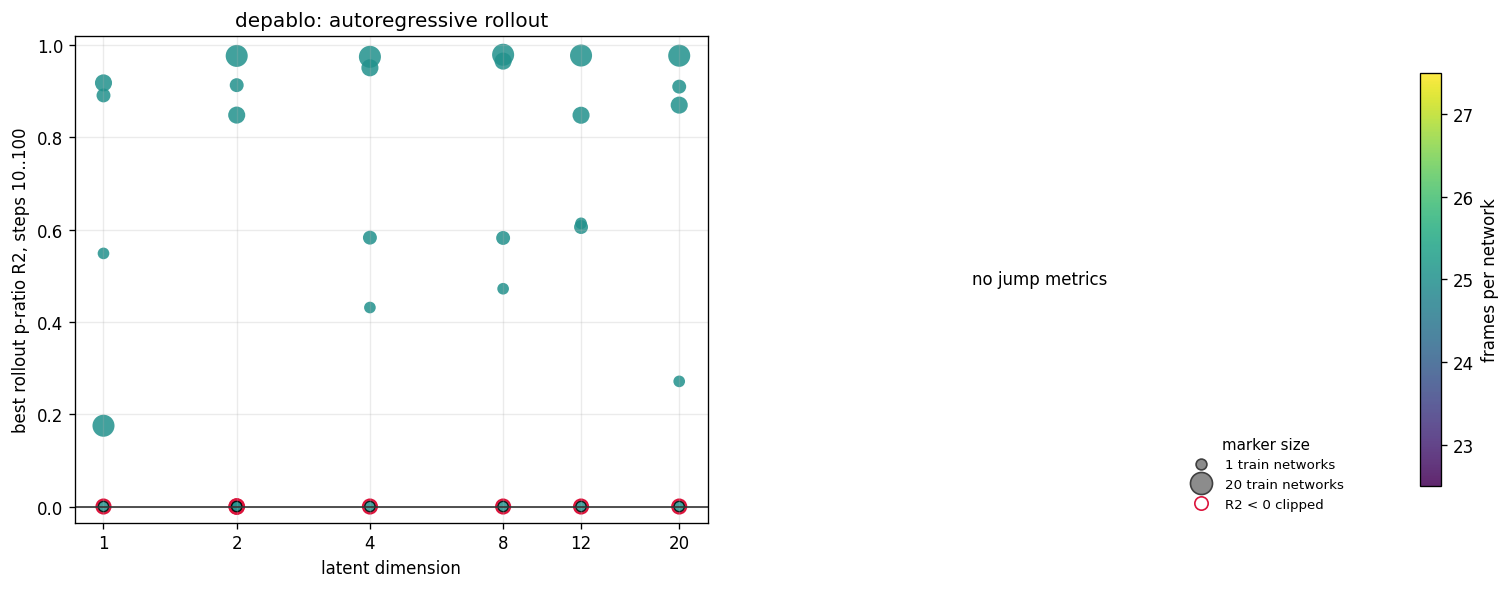

In [13]:
sweep_jump_stats_df = pd.DataFrame()
sweep_jump_raw_df = pd.DataFrame()
sweep_jump_history_df = pd.DataFrame()
sweep_plot_dir = run_dir / 'sweep_plots'
sweep_plot_dir.mkdir(parents=True, exist_ok=True)

summary_key_cols = ['dataset_name', 'target_mode', 'latent_dim', 'train_networks', 'train_frames_per_network']

if not isinstance(sweep_rollout_stats_df, pd.DataFrame) or sweep_rollout_stats_df.empty:
    print('No rollout stats are available. Run the sweep cell first.')
else:
    rollout = sweep_rollout_stats_df.copy()
    rollout = rollout[rollout['rollout_steps'].between(10, 100)].copy()
    rollout_repeat = rollout.groupby(summary_key_cols + ['repeat_idx', 'rollout_steps'], as_index=False).agg(
        rollout_position_mse=('final_pos_mse', 'mean'),
        rollout_p_ratio_r2=('p_ratio_r2', 'mean'),
        rollout_p_ratio_mse=('p_ratio_mse', 'mean'),
        used=('used', 'mean'),
    )
    rollout_summary_df = rollout_repeat.groupby(summary_key_cols + ['rollout_steps'], as_index=False).agg(
        rollout_position_mse_mean=('rollout_position_mse', 'mean'),
        rollout_position_mse_std=('rollout_position_mse', 'std'),
        rollout_p_ratio_r2_mean=('rollout_p_ratio_r2', 'mean'),
        rollout_p_ratio_r2_std=('rollout_p_ratio_r2', 'std'),
        rollout_p_ratio_mse_mean=('rollout_p_ratio_mse', 'mean'),
        rollout_p_ratio_mse_std=('rollout_p_ratio_mse', 'std'),
        n_repeats=('repeat_idx', 'nunique'),
        used=('used', 'mean'),
    )
    rollout_summary_df[['rollout_position_mse_std', 'rollout_p_ratio_r2_std', 'rollout_p_ratio_mse_std']] = rollout_summary_df[['rollout_position_mse_std', 'rollout_p_ratio_r2_std', 'rollout_p_ratio_mse_std']].fillna(0.0)
    rollout_summary_df.to_csv(sweep_export_dir / 'rollout_10_100_summary.csv', index=False)
    rollout_repeat.to_csv(sweep_export_dir / 'rollout_10_100_by_repeat.csv', index=False)
    print('saved rollout summaries:', sweep_export_dir / 'rollout_10_100_summary.csv')

if isinstance(globals().get('sweep_jump_stats_df'), pd.DataFrame) and not sweep_jump_stats_df.empty:
    jump = sweep_jump_stats_df.copy()
    jump_repeat = jump.groupby(summary_key_cols + ['repeat_idx', 'jump_steps'], as_index=False).agg(
        jump_position_mse=('final_pos_mse', 'mean'),
        jump_p_ratio_r2=('p_ratio_r2', 'mean'),
        jump_p_ratio_mse=('p_ratio_mse', 'mean'),
        used=('used', 'mean'),
    )
    jump_summary_df = jump_repeat.groupby(summary_key_cols + ['jump_steps'], as_index=False).agg(
        jump_position_mse_mean=('jump_position_mse', 'mean'),
        jump_position_mse_std=('jump_position_mse', 'std'),
        jump_p_ratio_r2_mean=('jump_p_ratio_r2', 'mean'),
        jump_p_ratio_r2_std=('jump_p_ratio_r2', 'std'),
        jump_p_ratio_mse_mean=('jump_p_ratio_mse', 'mean'),
        jump_p_ratio_mse_std=('jump_p_ratio_mse', 'std'),
        n_repeats=('repeat_idx', 'nunique'),
        used=('used', 'mean'),
    )
    jump_summary_df[['jump_position_mse_std', 'jump_p_ratio_r2_std', 'jump_p_ratio_mse_std']] = jump_summary_df[['jump_position_mse_std', 'jump_p_ratio_r2_std', 'jump_p_ratio_mse_std']].fillna(0.0)
    jump_summary_df.to_csv(sweep_export_dir / 'jump_100_summary.csv', index=False)
    jump_repeat.to_csv(sweep_export_dir / 'jump_100_by_repeat.csv', index=False)
    print('saved jump summaries:', sweep_export_dir / 'jump_100_summary.csv')
else:
    jump_summary_df = pd.DataFrame()
    print('No jump stats are available yet.')

if isinstance(globals().get('initial_latent_summary_df'), pd.DataFrame) and not initial_latent_summary_df.empty:
    readout_summary = initial_latent_summary_df.copy()
elif (sweep_export_dir / 'initial_latent_pratio_readout_summary.csv').exists():
    readout_summary = pd.read_csv(sweep_export_dir / 'initial_latent_pratio_readout_summary.csv')
else:
    readout_summary = pd.DataFrame()

if 'rollout_summary_df' in globals() and isinstance(rollout_summary_df, pd.DataFrame) and not rollout_summary_df.empty:
    final_summary_df = rollout_summary_df.copy()
    if not jump_summary_df.empty:
        final_summary_df = final_summary_df.merge(jump_summary_df, on=summary_key_cols, how='left', suffixes=('', '_jump'))
    if not readout_summary.empty:
        readout_cols = summary_key_cols + [col for col in ['single_test_r2_mean', 'single_test_r2_std', 'combo_test_r2_mean', 'combo_test_r2_std'] if col in readout_summary.columns]
        final_summary_df = final_summary_df.merge(readout_summary[readout_cols], on=summary_key_cols, how='left')
    final_summary_df.to_csv(sweep_export_dir / 'all_sweep_metric_summary.csv', index=False)
    print('saved combined summary:', sweep_export_dir / 'all_sweep_metric_summary.csv')
    display_cols = [
        'dataset_name', 'latent_dim', 'train_networks', 'train_frames_per_network', 'rollout_steps',
        'combo_test_r2_mean', 'rollout_p_ratio_r2_mean', 'rollout_position_mse_mean',
        'jump_p_ratio_r2_mean', 'jump_position_mse_mean',
    ]
    display_cols = [col for col in display_cols if col in final_summary_df.columns]
    print(final_summary_df[display_cols].head(80).round(4).to_string(index=False))

    # Compact overview: best p-ratio R2 over 10..100 rollout steps, plus direct +100 jump R2.
    # Negative R2 values are clipped to 0 for the plotted domain, but clipped points get
    # an outlined marker at the baseline so they remain visible.
    def _marker_size(train_networks):
        return 35 + 7 * np.asarray(train_networks, dtype=float)

    def _scatter_r2(ax, df, metric_col, *, title, ylabel):
        raw_y = df[metric_col].to_numpy(dtype=float)
        plot_y = np.clip(raw_y, 0.0, 1.0)
        sizes = _marker_size(df['train_networks'])
        sc = ax.scatter(
            df['latent_dim'],
            plot_y,
            c=df['train_frames_per_network'],
            s=sizes,
            cmap='viridis',
            alpha=0.85,
            edgecolors=np.where(raw_y < 0, 'black', 'none'),
            linewidths=np.where(raw_y < 0, 1.15, 0.0),
        )
        neg = np.isfinite(raw_y) & (raw_y < 0)
        if neg.any():
            ax.scatter(
                df.loc[neg, 'latent_dim'],
                np.zeros(int(neg.sum())),
                facecolors='none',
                edgecolors='crimson',
                s=sizes[neg] + 28,
                linewidths=1.3,
                label='R2 < 0, clipped to 0',
            )
        ax.set_xscale('log', base=2)
        ax.set_xticks(latent_dims)
        ax.set_xticklabels([str(x) for x in latent_dims])
        ax.set_ylim(-0.035, 1.02)
        ax.axhline(0, color='0.2', lw=1.0)
        ax.set_xlabel('latent dimension')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(alpha=0.25)
        return sc

    best_rollout = final_summary_df.sort_values('rollout_p_ratio_r2_mean', ascending=False).groupby(summary_key_cols, as_index=False).head(1)
    for dataset_name, dataset_df in best_rollout.groupby('dataset_name'):
        fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), constrained_layout=True)
        sc = _scatter_r2(
            axes[0],
            dataset_df,
            'rollout_p_ratio_r2_mean',
            title=f'{dataset_name}: autoregressive rollout',
            ylabel='best rollout p-ratio R2, steps 10..100',
        )
        if 'jump_p_ratio_r2_mean' in dataset_df:
            _scatter_r2(
                axes[1],
                dataset_df.dropna(subset=['jump_p_ratio_r2_mean']),
                'jump_p_ratio_r2_mean',
                title=f'{dataset_name}: direct jump',
                ylabel='direct +100 p-ratio R2',
            )
        else:
            axes[1].text(0.5, 0.5, 'no jump metrics', transform=axes[1].transAxes, ha='center', va='center')
            axes[1].set_axis_off()

        frame_cbar = fig.colorbar(sc, ax=axes, label='frames per network', shrink=0.85)
        network_counts = sorted(dataset_df['train_networks'].dropna().astype(int).unique())
        if network_counts:
            legend_counts = [network_counts[0], network_counts[-1]] if network_counts[0] != network_counts[-1] else [network_counts[0]]
            size_handles = [
                plt.Line2D(
                    [], [],
                    marker='o',
                    linestyle='none',
                    markerfacecolor='0.55',
                    markeredgecolor='0.25',
                    markersize=np.sqrt(_marker_size([count])[0]),
                    label=f'{count} train networks',
                )
                for count in legend_counts
            ]
            clip_handle = plt.Line2D([], [], marker='o', linestyle='none', markerfacecolor='none', markeredgecolor='crimson', markersize=8, label='R2 < 0 clipped')
            axes[1].legend(handles=size_handles + [clip_handle], title='marker size', frameon=False, loc='lower right', fontsize=8, title_fontsize=9)
        fig.savefig(sweep_plot_dir / f'{dataset_name}_pratio_r2_overview.png', dpi=220, bbox_inches='tight')
        plt.show()
else:
    print('No final summary generated.')



## Exports


In [14]:
if isinstance(globals().get('sweep_model_manifest_df'), pd.DataFrame) and not sweep_model_manifest_df.empty:
    existing = int(sweep_model_manifest_df['exists'].sum())
    total = int(len(sweep_model_manifest_df))
    print(f'Saved model bundles available: {existing}/{total}')
else:
    print('No model manifest is loaded yet. Run the sweep model cell first.')


Saved model bundles available: 90/90
